# Lesson 195 · Thesis stress-test

Tier B: real saved RelBench prediction evidence. This offline NumPy notebook replays all approved runs. It trains no model. Author-reference figures below precede your kernel outputs; successful execution is not your written defense.

In [ ]:
# @colab-bootstrap
# No download, checkout, model load, or paid API. Requires NumPy.
import base64, hashlib, io, json, math, tempfile, zipfile
from pathlib import Path
import numpy as np
workspace=Path(tempfile.mkdtemp(prefix="l195-stress-"))

<p class="eyebrow">YEAR 5 · LESSON 195 · THESIS STRESS-TEST</p>

# What would change your mind?

**Your tangible win:** write the strongest defensible case against the thesis, then state the observation that would change your mind. The goal is a better research question for Year 6.

[Lesson 194](https://avistian.github.io/relational/lessons/0194-open-fm-analysis-report.html) separated observations from explanations. This lesson asks what those observations do to the argument itself. It introduces no new model. You will reproduce the complete approved **saved-evidence analysis**, using visible scoring code.

<div class="repro-status"><strong>Complete selected replay:</strong> 33,650 saved predictions rescored. No new training or inference. RDBLearn full model reproduction remains INCOMPLETE_SOURCE_PREPROCESSING_GATE. Learner defense pending.</div>







## 1 · Make the thesis testable

**Mission connection.** The mission asks whether relational learning unlocks overlooked value. To test that claim, first make it possible to be wrong. A **falsifier** is an observation that would contradict a specified claim under a valid measurement procedure. It is not simply an inconvenient number.

## 2 · Split the thesis before attacking it

**In plain terms.** “Relationships matter,” “this model uses them better,” and “the world undervalues it” are different propositions.

The dossier has four subclaims. **C1** says flattening can discard useful information. **C2** says learning over structure can recover predictive value. **C3** requires a fair, robust advantage. **C4** claims the opportunity is undervalued. Here, *flattening* means representing a target entity and its history as one fixed-width row; a *relational feature* can still summarize records from other tables.

<figure class="repro-figure">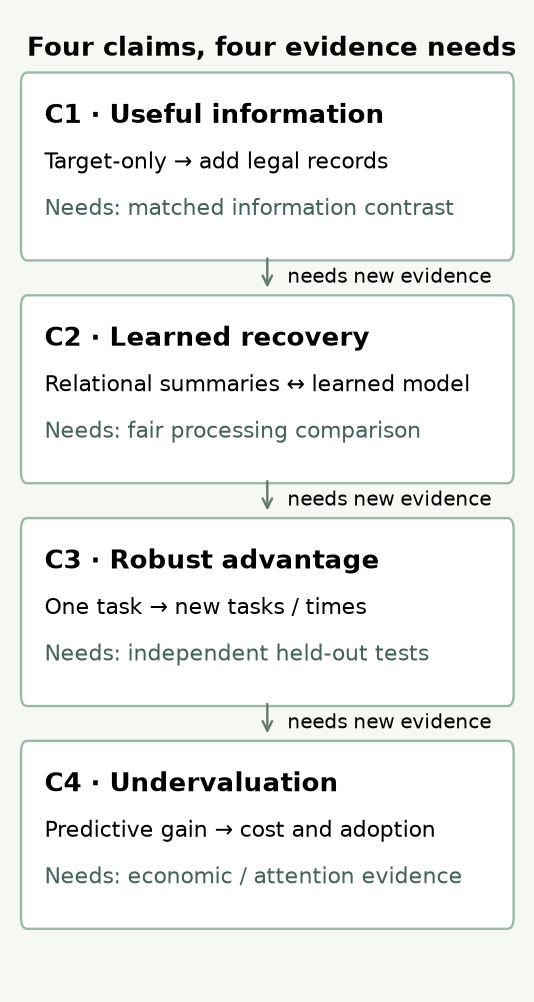<figcaption>Each arrow needs additional evidence. A predictive comparison cannot fill a missing information intervention, robustness test, or economic measurement.</figcaption></figure>

**Worked example.** A table with customer ID, order count and last-month spend already contains relational information. LightGBM on that table is a tabular predictor with relational features. Comparing it with a graph neural network changes the processing pipeline. It does not compare “relationships” with “no relationships.”

**The strongest alternative.** Deterministic relational summaries plus a strong tabular predictor may be sufficient for some tasks. [RDBLearn v1, §3](https://arxiv.org/html/2602.18495v1#S3) makes this an explicit two-stage recipe. That is an objection to the *necessity of learned relational encoders*, not to using relational records at all.

A feature-map collision proves that particular map loses information. It does not prove that the missing information predicts the target, or that every feasible feature map loses it. Likewise, repeated ties on a few flat datasets do not prove single-table progress is exhausted. Some early dossier language made that stronger leap; this lesson narrows it.

## 3 · Start with the uncomfortable result


<p>Predict before reading: lower mean error for engineered features challenges a universal GNN advantage; it does not prove relational information is useless.</p>

The first packet comes from [L149](https://avistian.github.io/relational/lessons/0149-weakest-relbench-tasks.html): basic GraphSAGE RDL versus engineered relational features plus LightGBM on **rel-f1/driver-position**. RDL means relational deep learning. The target is future average finishing position. **MAE**, mean absolute error, averages the absolute distance between prediction and target; smaller is better.

**Held fixed:** the archived query identities, outcomes and evaluation splits. **Compared:** two released complete pipelines, including different preprocessing and learning procedures. Each has five saved runs. The GNN ran ten full epochs per seed; the feature baseline ran ten validation trials per seed followed by its selected refit. Every validation and test prediction is retained.

**Worked arithmetic.** Define candidate advantage as baseline loss minus candidate loss. For these GNN and feature-baseline test means, `3.948917 − 4.123071 = −0.174155` position units. Negative favors the feature baseline. For one illustrative query with truth `4`, GNN prediction `6` and baseline prediction `5`, the advantage is `|4−5| − |4−6| = −1`. The illustrative query is not a measured driver row.

<figure class="repro-figure">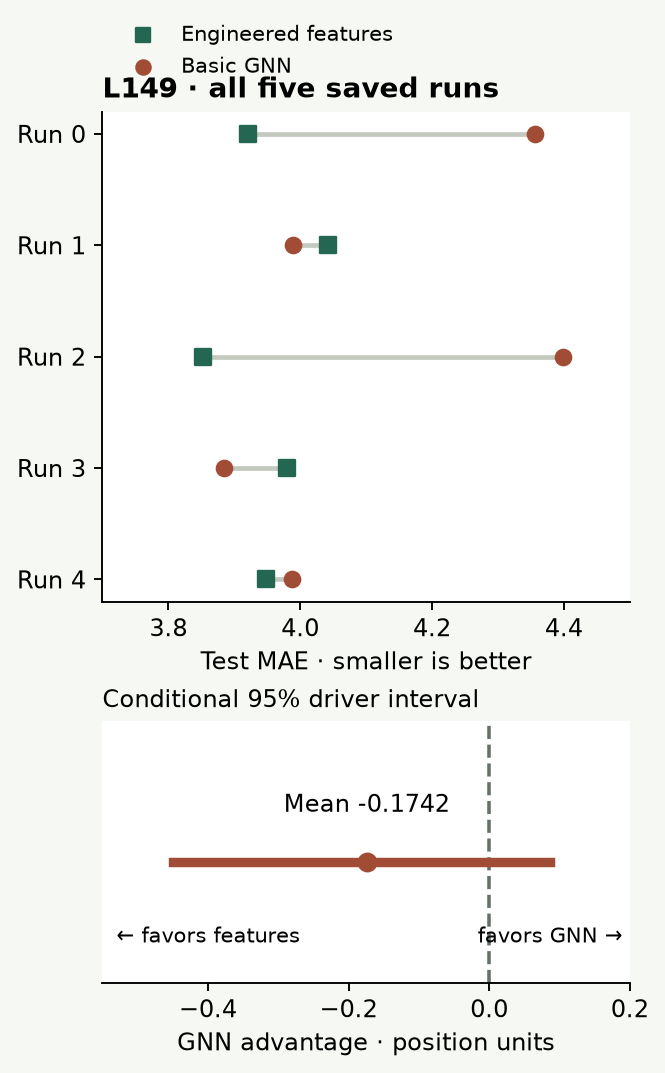<figcaption>Stored test predictions, rescored in L195. Each line joins the same run index, not shared training randomness. The interval resamples 56 drivers after averaging query losses across runs; it does not describe new databases.</figcaption></figure>

**Uncertainty has a unit.** Several predictions concern the same driver, so independently resampling individual rows would ignore that grouping. We first average each query's loss difference over the five saved runs, then resample whole drivers with replacement. We retain query weighting within each draw. The 2.5th and 97.5th percentiles of 2,000 draws form a **conditional descriptive interval**: `[-0.449621, +0.085850]` for GNN advantage.

**Trace one clustered resample.** Use a tiny hypothetical set: driver A has two query advantages `[+1,+1]`, and driver B has one `[-1]`. Positive favors the candidate. The original query-weighted mean is `(+1 + 1 − 1)/3 = 1/3`. Resampling two drivers with replacement yields:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Driver draw</th><th>Query values</th><th>Draw mean</th></tr></thead><tbody><tr><td>A, A</td><td>+1,+1,+1,+1</td><td>1</td></tr><tr><td>A, B</td><td>+1,+1,−1</td><td>1/3</td></tr><tr><td>B, B</td><td>−1,−1</td><td>−1</td></tr></tbody></table>

B,A has the same mean as A,B. A selected driver's entire block travels together; selecting A twice repeats both of its queries. Averaging driver means instead would give zero in the mixed draw. That would change the weighting rule, not merely the resampling unit. This toy explains the algorithm; its three queries are not extra F1 evidence.

**Transfer the trace.** Give B two identical −1 queries. The mixed draw and original mean both become zero; equal-driver and equal-query weighting now coincide because block sizes match. State both the resampling unit and weighting rule when reporting uncertainty.


It crosses zero. This does not demonstrate a reliable GNN advantage, and it does not prove equivalence or a universal feature-engineering victory. The interval holds the fitted models and split fixed. It does not cover new-database uncertainty or dependence between drivers in the same race. The test set has been examined in earlier lessons, so this is exploratory evidence.

> **Scope check.** This is the basic GNN associated with [RelBench v1 Table 7](https://arxiv.org/html/2407.20060v1), not the boosted GNN used in the paper's regression user-study figure. Historical feature arrival times remain unknown. Replaying stored predictions does not retrain either pipeline.

### Try a practical margin

A **practical margin** is the smallest benefit worth the added complexity, expressed in the task's units. It must be chosen before a future confirmatory test. Here you can change a margin retrospectively while the measured interval stays fixed. This exposes how a decision depends on the requirement; it does not validate a convenient threshold.


<p>At the baseline margin 0, the measured interval crosses zero: UNRESOLVED. At margin 0.50, it lies within the chosen band; that geometry alone does not establish equivalence.</p>

## 4 · Keep evidence that pushes the other way

The second packet is the complete selected L182 inference evidence, preserved through [L190](https://avistian.github.io/relational/lessons/0190-research-gap-checkpoint.html): RDB-PFN, its single-table-prior variant, and TabICL v1.1. There are ten support draws, each with 512 labeled support examples, and all 702 test queries. A **support draw** chooses labeled examples supplied to a frozen predictor; it is not a new database or new pretraining run.

**AUROC** measures how often a randomly chosen positive ranks above a negative, giving half credit to tied scores. Larger is better. We preserve the released label orientation and full `(entity ID, cutoff)` keys. A **cutoff** is the prediction time associated with an entity; entity ID alone cannot identify repeated queries.

<figure class="repro-figure">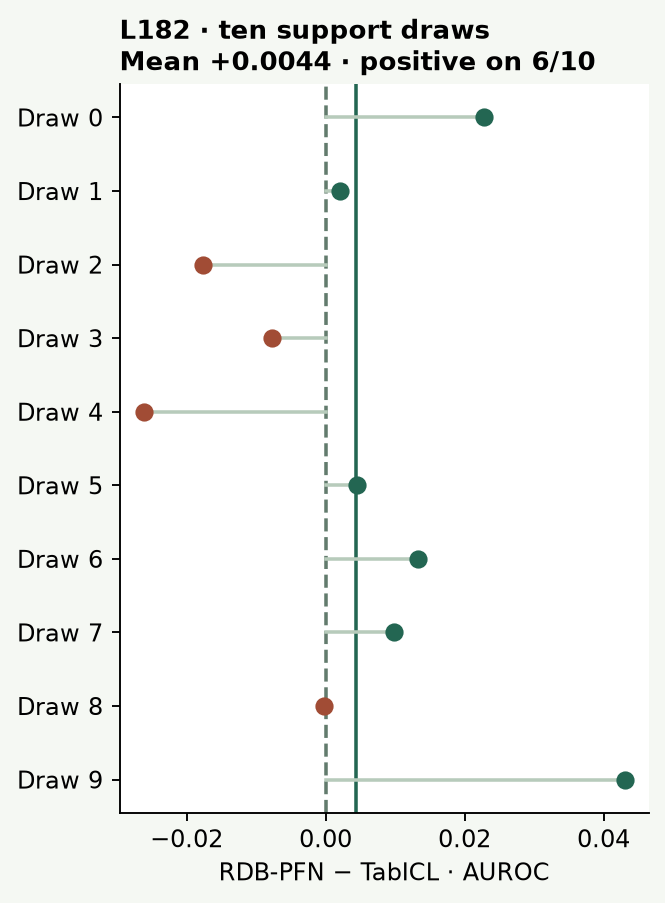<figcaption>Stored L182 predictions, rescored in L195. Each point contrasts the same support draw and test queries. Ten draws reuse one F1 task; the mean line is not a confidence interval.</figcaption></figure>

RDB-PFN minus TabICL averages **+0.004369 AUROC**, with positive differences on **6/10** support draws. The ten dots describe support sensitivity on this one task; they are not ten independent replications. [RDB-PFN v5, §6 and Table 9](https://arxiv.org/html/2603.03805v5) provide the published context. This selected replay cannot establish the paper's broader task claims.

**Steelman the skeptic.** A strong tabular FM using relational summaries is a serious comparator; the selected gain is not uniformly positive across support draws. **Steelman the reply.** The relational-prior model still has a positive mean here, and its single-table-prior variant is weaker. That leaves a useful research hypothesis. Comparing these saved systems does not identify architecture or pretraining prior as the sole cause.

## 5 · An unrun experiment is not a loss

L194 retains all **21** RDBLearn tasks and the full planned search: **567** validation candidates and **63** selected tests. All fresh scores remain absent because the source/preprocessing admission gate failed. Published reference values give **17 favorable / 3 unfavorable / 1 equal** signs against the fixed AutoGluon+DFS comparator. Those are descriptive paper-table signs, not new predictions or significance results.

The recorded category-code failure is evidence about representation consistency. Its benchmark frequency and score impact remain unmeasured. The remaining data, availability, checkpoint, regression-normalization and executor gaps also remain. **The strongest criticism is currently reproducibility and readiness, not measured predictive inferiority.**


<p>Both measured replay packets support scoped pipeline comparisons. The unrun RDBLearn packet supports no fresh performance conclusion. None of these packets establishes causal architecture effects, broad superiority, or economic undervaluation.</p>

**Non-independent data and open environments.** Rows may share an entity, event or time period. Converting them to one table does not make them independent. New time periods, unseen entities, changed feature schemas or new label classes can challenge a method beyond its original evaluation contract. [L069](https://avistian.github.io/relational/lessons/0069-tabpfn-open-environment-failures.html) and its [primary reading](https://arxiv.org/abs/2505.16226) give concrete open-environment cases. These are reasons to design new tests; their results are not numerically replayed in this lesson.

## 6 · Write a falsification brief that could change a decision

Use four short parts: **claim → strongest objection → what survives → decisive next observation**. Avoid a vague verdict such as “the thesis is wrong.” Specify the scope you are revising.

**Worked reference position.** “The evidence does not establish that learned relational encoders are necessary for strong relational prediction. Engineered relational features are competitive in the selected F1 comparison, whose conditional interval leaves the direction unresolved. A positive RDB-PFN contrast keeps relational priors interesting. I would test matched information access on new tasks, with a practical margin and a group-aware uncertainty procedure declared before test access.”

For C4, even a robust predictive win would leave **undervaluation** open. That claim needs a specified comparison of total cost, downstream utility and adoption or investment. A leaderboard score contains none of those measurements.

| Subclaim | Current defensible position | Missing decisive evidence |
|---|---|---|
| C1: useful structure can be lost | Possible; not inevitable for every task/map | Matched information intervention |
| C2: learned recovery helps | Task-dependent hypothesis; strong FE comparator | Matched pipeline and prior/architecture controls |
| C3: fair robust gain | Scoped results; broad advantage unestablished | New databases, time shifts, full uncertainty |
| C4: undervalued opportunity | Not measured by these scores | Cost, utility and adoption evidence |

**Future study, NOT_RUN.** Freeze target-only, legal relational-summary and learned-relational conditions on an untouched task set. Match information availability and validation search, disclose training/inference costs, and declare the minimally useful gain. A result that fails the practical-gain requirement would narrow a practical-superiority claim. Missing runs stay incomplete. This study needs its own feasible protocol and budget before execution.



## 7 · Implement, inspect, defend

The [student notebook](https://avistian.github.io/relational/labs/0195-thesis-stress-test.ipynb) is an offline NumPy lab. It embeds the complete evidence packet and readable scoring implementation. Your three TODOs align query errors, interpret interval geometry, and limit claims; the full replay calls your functions. CHECK cells give immediate feedback. Keep the written defense separate from automatic checks.

[Read-only executed notebook](https://avistian.github.io/relational/labs/html/0195-thesis-stress-test.html) · [Reference sheet](https://avistian.github.io/relational/reference/thesis-stress-test.html) · [Complete author falsification brief](https://avistian.github.io/relational/labs/evidence/l195/falsification-brief.md) · [Reproduction contract](https://avistian.github.io/relational/labs/l195-reproduction.md) · [Independent verification](https://avistian.github.io/relational/labs/_verify_l195_results.json).

**Exit ticket:** challenge one of C1–C4 using exact evidence, defend the strongest reply, and specify what would reverse your position. Name what varies, what stays fixed, the metric and units, the uncertainty unit, practical margin, and invalidation conditions. Ask the teacher to challenge your reasoning or explain any unclear step. Successful author replay leaves your status **PENDING_WRITTEN_DEFENSE**.

**Next:** [Lesson 196](https://avistian.github.io/relational/lessons/0196-community-engagement.html) turns an unresolved technical question into a precise community draft. [Lesson 197](https://avistian.github.io/relational/lessons/0197-year-5-essay.html) then connects your narrowed claim to the wider model landscape, before [Lesson 198](https://avistian.github.io/relational/lessons/0198-three-research-directions.html) develops three proposals. No community message is sent by this lesson.


## PROVIDED · Frozen evidence
The embedded archive preserves prediction arrays, receipts, original manifest chains, the L194 paper/task packet and source contracts. A matching hash proves identity to the snapshot; it does not prove historical feature availability. No earlier lesson folder is required.

In [ ]:
payload='...'
raw=base64.b64decode(payload)
assert hashlib.sha256(raw).hexdigest()=='5f43c6ec5e80df3887a4624ce3be1705e9b0d11add8ec6a77559974bf29130fc'
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist():
        if not (workspace/name).resolve().is_relative_to(workspace.resolve()): raise ValueError("Unsafe archive path")
    z.extractall(workspace)
packet=workspace/"packet"
manifest=json.loads((workspace/"input-manifest.json").read_text())

## TODO · paired_mae

Each input contains (entity, cutoff, value) triples. Reject duplicate, missing, extra or invalid numeric rows. Align predictions to truth order. Return keys, candidate_mae, baseline_mae and the per-query advantage list (baseline absolute error minus candidate absolute error). Use float64 Python arithmetic. Reordering predictions must not change the result.

Predict a failure case before running your CHECK. This function remains a live dependency of the full replay.

In [ ]:
def paired_mae(truth, candidate, baseline):
    raise NotImplementedError('paired_mae')

### CHECK · Test the contract

In [ ]:
t=[(1,10,2.),(1,20,4.)]
a=[(1,20,5.),(1,10,2.)];b=[(1,10,4.),(1,20,4.)]
x=paired_mae(t,a,b)
assert x['advantage']==[2.,-1.] and x['candidate_mae']==.5
try: paired_mae(t,a[:-1],b)
except ValueError: pass
else: raise AssertionError('Missing query accepted')
print("Contract PASS")

## TODO · interval_verdict

Validate a finite nonnegative numeric margin (not a boolean) and boolean completeness. Incomplete evidence returns INCOMPLETE. Otherwise require finite ordered endpoints. Apply the field-guide geometry: ABOVE_MARGIN, BELOW_NEGATIVE_MARGIN, WITHIN_MARGIN or UNRESOLVED. Keep strict inequality for directional decisions; the zero-width band never establishes equivalence.

Predict a failure case before running your CHECK. This function remains a live dependency of the full replay.

In [ ]:
def interval_verdict(low, high, margin, complete=True):
    raise NotImplementedError('interval_verdict')

### CHECK · Test the contract

In [ ]:
assert interval_verdict(-.45,.09,0)=='UNRESOLVED'
assert interval_verdict(-.45,.09,.5)=='WITHIN_MARGIN'
assert interval_verdict(None,None,.1,False)=='INCOMPLETE'
assert interval_verdict(.03,.08,.02)=='ABOVE_MARGIN'
try: interval_verdict(1,0,0)
except ValueError: pass
else: raise AssertionError('Reversed interval accepted')
print("Contract PASS")

## TODO · claim_scope

Implement this packet-specific policy. A pipeline claim requires authenticated, complete, measured and comparable to each be exactly True, giving SCOPED_COMPARISON; otherwise INSUFFICIENT_EVIDENCE. relational_signal, architecture_cause, general_superiority and undervaluation remain NOT_ESTABLISHED; fresh_training is NOT_RUN. Reject unknown claims. Explain what missing measurement would be needed for each stronger claim.

Predict a failure case before running your CHECK. This function remains a live dependency of the full replay.

In [ ]:
def claim_scope(claim, evidence):
    raise NotImplementedError('claim_scope')

### CHECK · Test the contract

In [ ]:
e=dict(authenticated=True,complete=True,measured=True,comparable=True)
assert claim_scope('pipeline',e)=='SCOPED_COMPARISON'
assert claim_scope('pipeline',dict(e,measured=False))=='INSUFFICIENT_EVIDENCE'
assert claim_scope('undervaluation',e)=='NOT_ESTABLISHED'
try: claim_scope('models always win',e)
except ValueError: pass
else: raise AssertionError('Unknown claim accepted')
print("Contract PASS")

## PROVIDED · Rank AUROC
Average tied ranks give half-credit for tied positive-negative scores. Full keys align repeated queries. This inherited visible scorer is independently checked against all positive-negative pairs by the repository verifier.

In [ ]:
def keyed_auc(truth, predictions):
    """Rank AUROC with half credit for ties, aligned by (entity_id, cutoff)."""
    def index(rows):
        result={}
        for row in rows:
            if len(row)!=3:raise ValueError('Expected entity, cutoff, value')
            a,b,v=row;key=(a,b)
            if key in result or not math.isfinite(v):raise ValueError('Duplicate key or nonfinite value')
            result[key]=v
        return result
    labels=index(truth);probs=index(predictions)
    if not labels or labels.keys()!=probs.keys():raise ValueError('Incomplete query identity')
    if set(labels.values())!={0,1}:raise ValueError('Both binary classes required')
    if any(not 0<=v<=1 for v in probs.values()):raise ValueError('Probabilities outside [0,1]')
    ordered=sorted((probs[k],labels[k]) for k in labels)
    rank_sum=0.;i=0
    while i<len(ordered):
        j=i+1
        while j<len(ordered) and ordered[j][0]==ordered[i][0]:j+=1
        rank_sum+=((i+1+j)/2)*sum(y for _,y in ordered[i:j]);i=j
    npos=sum(labels.values());nneg=len(labels)-npos
    return (rank_sum-npos*(npos+1)/2)/(npos*nneg)

## PROVIDED · Driver-cluster interval
Group query differences by driver, sample whole drivers with replacement, and retain query weighting in each draw. Models and split are held fixed. Read the group totals and counts: replacing these with unweighted driver means would change the estimand.

In [ ]:
def cluster_interval(delta, entities, draws=2000, seed=137):
    """Resample whole drivers; retain row weighting inside every bootstrap draw."""
    d=np.asarray(delta,dtype=float);e=np.asarray(entities)
    if d.ndim!=1 or e.shape!=d.shape or not len(d) or not np.isfinite(d).all():raise ValueError('Invalid aligned losses')
    if draws<2:raise ValueError('Need at least two draws')
    groups,inverse=np.unique(e,return_inverse=True);n=len(groups)
    if n<2:return dict(status='INSUFFICIENT_ENTITIES',mean=float(d.mean()),entities=n,low=None,high=None)
    totals=np.bincount(inverse,weights=d);counts=np.bincount(inverse)
    rng=np.random.default_rng(seed);samples=rng.integers(0,n,size=(draws,n))
    estimates=totals[samples].sum(axis=1)/counts[samples].sum(axis=1)
    lo,hi=np.quantile(estimates,[.025,.975])
    return dict(status='CONDITIONAL_DESCRIPTIVE',mean=float(d.mean()),entities=n,low=float(lo),high=float(hi),draws=draws,seed=seed)

## PROVIDED · Full replay operator
First authenticate bytes and original receipt chains. Then rescore every regression run; check validation selection; align common float64 targets. Next check all ICL runs against released keys, labels and support draws. Finally authenticate all21RDBLearn task rows and preserve missing scores. Your three functions control the result; none is replaced.

In [ ]:
def replay195(packet, manifest, pair, verdict, scope, auc, interval):
    import hashlib,json,math,statistics
    from pathlib import Path
    import numpy as np
    q=Path(packet).resolve()
    actual={str(p.relative_to(q)) for p in q.rglob('*') if p.is_file()}
    if actual!=set(manifest['files']):raise ValueError('Incomplete or extra input files')
    for name,h in manifest['files'].items():
        p=(q/name).resolve()
        if not p.is_relative_to(q) or hashlib.sha256(p.read_bytes()).hexdigest()!=h:raise ValueError('Input hash mismatch: '+name)
    read=lambda name:json.loads((q/name).read_text())
    origins=read('origins.json')
    for name,o in origins.items():
        if manifest['files'].get(name)!=o['sha256']:raise ValueError('Original input identity changed')
    old=read('l149/training.json');fe_summary=read('l149/fe/summary.json');errors=read('l149/errors.json')
    regress={};count=0;max_target_difference=0
    for split,n in [('val',499),('test',760)]:
        runs=[];deltas=[];truth_ref=None
        for seed in range(5):
            arrays={}
            for arm in ['gnn','fe']:
                folder=q/f'l149/{arm}/{seed}';r=read(f'l149/{arm}/{seed}/result.json')
                if r['seed']!=seed:raise ValueError('Wrong seed')
                file=folder/'predictions.npz';h=hashlib.sha256(file.read_bytes()).hexdigest()
                expected=old['files'][f'labs/evidence/l149/final/lr005-full/seed-{seed}/predictions.npz'] if arm=='gnn' else r['files']['predictions.npz']
                if h!=expected:raise ValueError('Prediction receipt mismatch')
                if arm=='gnn':
                    if len(r['trace'])!=10 or any(t['train_queries']!=7453 for t in r['trace']):raise ValueError('Incomplete training receipt')
                    if r['selected_epoch']!=min(r['trace'],key=lambda t:t['val_mae'])['epoch']:raise ValueError('Selection changed')
                elif r['trials']!=10:raise ValueError('Incomplete FE search receipt')
                with np.load(file,allow_pickle=False) as z:
                    arrays[arm]={k:z[split+'_'+k].tolist() for k in ['pred','target','entity','time']}
                a=arrays[arm]
                if any(len(v)!=n for v in a.values()):raise ValueError('Missing regression queries')
                own=math.fsum(abs(y-p) for y,p in zip(a['target'],a['pred']))/n
                if abs(own-r['scores'][split])>1e-6:raise ValueError('Original score differs')
            g,f=arrays['gnn'],arrays['fe'];keys=list(zip(f['entity'],f['time']));gkeys=list(zip(g['entity'],g['time']))
            if set(keys)!=set(gkeys) or len(set(keys))!=n:raise ValueError('Query population changed')
            gy=dict(zip(gkeys,g['target']));difference=max(abs(y-gy[k]) for k,y in zip(keys,f['target']))
            if difference>1e-6:raise ValueError('Target meanings differ')
            max_target_difference=max(max_target_difference,difference)
            truth=[(a,b,y) for (a,b),y in zip(keys,f['target'])]
            if truth_ref is None:truth_ref=truth
            if truth!=truth_ref:raise ValueError('Targets/keys change across seeds')
            p=pair(truth,[(a,b,v) for (a,b),v in zip(gkeys,g['pred'])],[(a,b,v) for (a,b),v in zip(keys,f['pred'])])
            runs.append(dict(seed=seed,gnn_mae=p['candidate_mae'],fe_mae=p['baseline_mae'],gnn_advantage=statistics.mean(p['advantage'])))
            deltas.append(p['advantage']);count+=2*n
        mean_delta=np.mean(deltas,axis=0);ci=interval(mean_delta,[a for a,b,y in truth_ref],draws=2000,seed=137)
        # Original L149 reports the opposite sign: GNN loss penalty.
        previous=errors['splits'][split]['slices']['all']['interval']
        if max(abs(ci['low']+previous['high']),abs(ci['high']+previous['low']))>1e-12:raise ValueError('Bootstrap interval changed')
        for arm,ref in [('gnn',old),('fe',fe_summary)]:
            if abs(statistics.mean(r[arm+'_mae'] for r in runs)-ref['metrics'][split]['mean'])>1e-6:raise ValueError('Inherited mean differs')
        regress[split]=dict(queries=n,runs=runs,gnn_mean=statistics.mean(r['gnn_mae'] for r in runs),fe_mean=statistics.mean(r['fe_mae'] for r in runs),gnn_sd=statistics.stdev(r['gnn_mae'] for r in runs),fe_sd=statistics.stdev(r['fe_mae'] for r in runs),gnn_advantage=float(mean_delta.mean()),conditional_interval=ci,zero_margin_verdict=verdict(ci['low'],ci['high'],0),scope='Conditional descriptive driver bootstrap; fixed models/split; repeated race/time dependence not covered')
    m190=read('l182/l190-input-manifest.json')
    for name,h in m190['files'].items():
        if name.startswith('model/') or name=='reports/l182.json':
            if manifest['files'].get('l182/'+name)!=h:raise ValueError('L190 origin chain mismatch')
    with np.load(q/'l182/model/prepared.npz',allow_pickle=False) as z:
        keys=z['test_keys'].tolist();labels=z['y_test'].tolist();supports={s:z['train_keys'][z['support'][s]].tolist() for s in range(10)}
    if len(keys)!=702 or len(set(map(tuple,keys)))!=702 or len(labels)!=702:raise ValueError('Released identity incomplete')
    truth=[(a,b,y) for (a,b),y in zip(keys,labels)]
    arms=['RDBPFN','RDBPFN_single','TabICLv1.1'];by={a:{} for a in arms};runs=[];seen=set()
    for folder in ['pilot-1','full-1']:
        receipt=read(f'l182/model/{folder}/receipt.json')
        if hashlib.sha256((q/'l182/original-input-manifest.json').read_bytes()).hexdigest()!=receipt['input_manifest_sha256']:raise ValueError('Original checkpoint/data manifest differs')
        for record in receipt['records']:
            arm,seed=record['arm'],record['seed'];ident=(arm,seed)
            if arm not in arms or seed not in range(10) or ident in seen:raise ValueError('Duplicate or extra ICL run')
            seen.add(ident);p=q/f'l182/model/{folder}/{arm}-{seed}.npz'
            if hashlib.sha256(p.read_bytes()).hexdigest()!=record['sha256']:raise ValueError('ICL receipt hash differs')
            with np.load(p,allow_pickle=False) as z:
                k=z['keys'].tolist();y=z['label'].tolist();prob=z['probability'].tolist();support=z['support_keys'].tolist()
            if k!=keys or y!=labels or len(prob)!=702:raise ValueError('Released queries or labels changed')
            if support!=supports[seed] or len(support)!=512 or len(set(map(tuple,support)))!=512:raise ValueError('Support draw differs')
            if set(map(tuple,k))&set(map(tuple,support)) or max(b for a,b in support)>=min(b for a,b in k):raise ValueError('Support contamination')
            score=auc(truth,[(a,b,v) for (a,b),v in zip(k,prob)])
            if abs(score-record['auc'])>1e-12 or record['rows']!=702:raise ValueError('ICL score differs')
            by[arm][seed]=score;runs.append(dict(arm=arm,seed=seed,auc=score));count+=702
    if seen!={(a,s) for a in arms for s in range(10)}:raise ValueError('Incomplete ICL grid')
    models={a:dict(mean=statistics.mean(by[a].values()),sample_sd=statistics.stdev(by[a].values()),per_seed=[by[a][s] for s in range(10)]) for a in arms}
    inherited=read('l182/reports/l182.json')
    for a in arms:
        if abs(models[a]['mean']-inherited['models'][a]['mean'])>1e-12:raise ValueError('ICL aggregate differs')
    differences=[by['RDBPFN'][s]-by['TabICLv1.1'][s] for s in range(10)]
    icl=dict(queries=702,support=512,runs=sorted(runs,key=lambda x:(x['arm'],x['seed'])),models=models,advantage=dict(mean=statistics.mean(differences),sample_sd=statistics.stdev(differences),per_seed=differences,positive=sum(d>0 for d in differences)),scope='Ten support draws on one task, not independent databases; no confidence interval for cross-database generalization')
    m194=read('l194/input-manifest.json')
    for name,h in m194['files'].items():
        if manifest['files'].get('l194/packet/'+name)!=h:raise ValueError('L194 origin chain mismatch')
    r194=read('l194/report.json');tasks=read('l194/packet/tasks.json');ids={t['id'] for t in tasks};rows=r194['task_results']
    if len(ids)!=21 or len(rows)!=21 or {r['task'] for r in rows}!=ids:raise ValueError('Incomplete L194 task report')
    if r194['status']!='INCOMPLETE_SOURCE_PREPROCESSING_GATE' or r194['executed_model_evaluations']!=0:raise ValueError('Unrun status changed')
    if any(r['fresh_mean'] is not None or r['fresh_sd'] is not None or r['completed_seeds']!=0 or r['fresh_gap'] is not None or r['status']!='NOT_RUN' for r in rows):raise ValueError('Invented fresh results')
    if r194['comparator']!='AutoGluon+DFS':raise ValueError('Comparator changed')
    for r in rows:
        d=(r['paper_model']-r['paper_comparator'])*(1 if r['metric']=='AUROC' else -1)
        if abs(d-r['gap'])>1e-12:raise ValueError('Reference gap differs')
    signs=[sum(r['gap']>0 for r in rows),sum(r['gap']<0 for r in rows),sum(r['gap']==0 for r in rows)]
    if signs!=[17,3,1]:raise ValueError('Reference signs differ')
    evidence=dict(authenticated=True,complete=True,measured=True,comparable=True)
    claims={c:scope(c,evidence) for c in ['pipeline','relational_signal','architecture_cause','general_superiority','undervaluation','fresh_training']}
    if claims!={'pipeline':'SCOPED_COMPARISON','relational_signal':'NOT_ESTABLISHED','architecture_cause':'NOT_ESTABLISHED','general_superiority':'NOT_ESTABLISHED','undervaluation':'NOT_ESTABLISHED','fresh_training':'NOT_RUN'}:raise ValueError('Unsupported claim promotion')
    return dict(experiment='L195 complete thesis stress-test replay',status='COMPLETE_SELECTED_REPLAY',authenticated_files=len(actual),prediction_rows=count,regression=regress,icl=icl,rdblearn=dict(status=r194['status'],tasks=rows,reference_signs=signs,fresh_tasks=0,planned_validation=567,planned_test=63),precision=dict(scoring='float64 from stored predictions',maximum_saved_target_difference=max_target_difference,gnn_internal_target_cast='Original training used float32; common scoring uses saved FE float64 archive targets'),claims=claims,whole_paper='NOT_RUN',historical_identity='NOT_ESTABLISHED',independent_replication=False,learner='PENDING_WRITTEN_DEFENSE',cloud_usd=0)

## PROVIDED · Falsification brief renderer
Read how a scoped numerical comparison becomes a qualified claim, counterargument and future revision condition.

In [ ]:
def brief_markdown(r):
    g=r['regression']['test'];c=g['conditional_interval'];i=r['icl']['advantage']
    lines=['# Lesson 195 — falsification brief','', '**Verdict: narrow the thesis; broad superiority and undervaluation remain unestablished.** This is an author reference defense, not the learner submission.','', '## Replayed evidence','',f"All {r['prediction_rows']:,} stored predictions were rescored: L149 five runs per pipeline on 499 validation and 760 test queries, and L182 three arms × ten support draws × 702 test queries. Hash chains retain original receipts. Reusing these results is not an independent replication.",'',f"L149 test GNN MAE {g['gnn_mean']:.6f}; engineered-feature LightGBM MAE {g['fe_mean']:.6f}. GNN advantage (FE minus GNN loss) {g['gnn_advantage']:+.6f}, conditional 95% driver-cluster interval [{c['low']:.6f}, {c['high']:.6f}]. This interval crosses zero. It establishes neither superiority nor equivalence. Both pipelines use relational information. The basic GNN is not the boosted GNN in the paper's Figure 3.",'',f"L182 RDB-PFN minus TabICL mean {i['mean']:+.6f} AUROC; positive on {i['positive']}/10 support draws. Both consume released DFS features. These observations compare saved systems, not the presence versus absence of relational data. Same task, reused test population and uncertain historical feature availability limit generalization.",'','L194 retains all 21 tasks: 17 favorable, 3 unfavorable and 1 equal published reference signs against AutoGluon+DFS; every fresh result remains missing. The preprocessing stop is a reproducibility obstacle, not a measured performance defeat. Model reproduction INCOMPLETE_SOURCE_PREPROCESSING_GATE.','', '## Strongest objections, replies and revision conditions','', '| Claim | Strongest objection from this evidence | What survives | What would change the verdict |','|---|---|---|---|', '| C1: flattening can lose useful signal | A collision in one feature map does not show every feasible feature map loses task-relevant signal. | Information loss can occur; predictive impact is task-dependent. | Predeclared same-backend comparison of target-only versus legal relational features on new tasks; label access and budget matched. |', '| C2: learned structure recovers value | Engineered relational features have lower mean error in L149; RDBLearn offers a strong aggregation-plus-tabular alternative. | A learned prior can still help; L182 has a positive mean against TabICL on this one task. | Compare strong relational FE and learned systems with matched information access, validation search and declared compute; separate architecture and prior interventions. |', '| C3: the advantage is fair and robust | L149 uncertainty crosses zero; L182 support draws are not databases; L194 has no fresh scores. | Scoped replay is reproducible. | New held-out databases and temporal shifts, point-in-time features, complete runs, predeclared practical margin and uncertainty unit. |', '| C4: the field undervalues it | Predictive scores contain no adoption, total engineering cost or economic valuation measurement. | Undervaluation remains a research hypothesis. | Measure total human/compute/serving cost and downstream utility against a specified adoption or investment benchmark. |','', '## Guard against a moving target','','Do not repair an unfavorable result by redefining the comparator, switching the unit of analysis, dropping a task, or moving a practical margin after seeing the score. The interactive margin sweep is explicitly retrospective sensitivity, not a preregistered test. A future confirmatory study must specify its target population, minimally useful benefit, measurement unit and stop rule before test access.','','Observational rows may share entities, events and time. One-table serialization does not create independent observations. The driver bootstrap preserves within-driver dependence, but not shared race/time or new-database uncertainty. Legal event cutoffs alone do not recover unknown historical arrival times.','','## Next decisive study — NOT_RUN','','On a new untouched task set, freeze three information/representation conditions: target-only features; legal relational summaries; learned relational processing with the same available information. Tune only on validation with a declared search budget. Measure task-specific predictive benefit, uncertainty at the appropriate group/database level, and total engineering/serving cost. Predeclare the practical margin in domain units. A valid interval wholly below the required benefit challenges a practical-superiority claim; missing runs never count as a loss. This is a study design, not an executed intervention.','','## Complete published reference inventory','','| Task | Metric | RDBLearn | AutoGluon+DFS | Fresh score |','|---|---|---:|---:|---|']
    for row in r['rdblearn']['tasks']:lines.append(f"| {row['task']} | {row['metric']} | {row['paper_model']:.4f} | {row['paper_comparator']:.4f} | NOT_RUN |")
    lines+=['','## Sources and limits','','[RelBench v1](https://arxiv.org/html/2407.20060v1) · [RDB-PFN v5](https://arxiv.org/html/2603.03805v5) · [RDBLearn v1](https://arxiv.org/html/2602.18495v1). Source revisions, original training protocols and numerical deviations are preserved in packet/contracts/. Complete selected replay; no fresh training, raw database reconstruction, whole-paper reproduction, causal architecture attribution, economic valuation or learner mastery. $0 cloud/API; 1800 seconds aggregate local execution cap.','']
    return '\n'.join(lines)

## CHECK · Complete replay
Compare your report with the authenticated author-reference analysis. This certifies replay consistency, not model training or mastery.

In [ ]:
report=replay195(packet,manifest,paired_mae,interval_verdict,claim_scope,keyed_auc,cluster_interval)
assert report==json.loads('{"authenticated_files": 80, "claims": {"architecture_cause": "NOT_ESTABLISHED", "fresh_training": "NOT_RUN", "general_superiority": "NOT_ESTABLISHED", "pipeline": "SCOPED_COMPARISON", "relational_signal": "NOT_ESTABLISHED", "undervaluation": "NOT_ESTABLISHED"}, "cloud_usd": 0, "experiment": "L195 complete thesis stress-test replay", "historical_identity": "NOT_ESTABLISHED", "icl": {"advantage": {"mean": 0.00436929683306495, "per_seed": [0.022729712584785067, 0.002015322305177314, -0.017606011808910305, -0.007661152588688824, -0.02619431025228125, 0.004552774117991487, 0.013267945152003136, 0.009822866344605496, -0.00028302347142927786, 0.04304884594739666], "positive": 6, "sample_sd": 0.0198077949697135}, "models": {"RDBPFN": {"mean": 0.7219377348362855, "per_seed": [0.7383984775289123, 0.7175523349436392, 0.7038598545844923, 0.7255941053042503, 0.6823598301859172, 0.7242277850973503, 0.7217342507197579, 0.7440491875274484, 0.7114917288830332, 0.7501097935880544], "sample_sd": 0.019982667847990538}, "RDBPFN_single": {"mean": 0.6639896550041477, "per_seed": [0.6116234811886986, 0.687180988630264, 0.6655638510710975, 0.6885375494071146, 0.6797443029327087, 0.6583711511247743, 0.6154686966281169, 0.6305274971941639, 0.6955838579026985, 0.7072951739618406], "sample_sd": 0.03417677717319856}, "TabICLv1.1": {"mean": 0.7175684380032206, "per_seed": [0.7156687649441272, 0.7155370126384619, 0.7214658663934026, 0.7332552578929391, 0.7085541404381984, 0.7196750109793588, 0.7084663055677548, 0.7342263211828429, 0.7117747523544625, 0.7070609476406577], "sample_sd": 0.00976959545029791}}, "queries": 702, "runs": [{"arm": "RDBPFN", "auc": 0.7383984775289123, "seed": 0}, {"arm": "RDBPFN", "auc": 0.7175523349436392, "seed": 1}, {"arm": "RDBPFN", "auc": 0.7038598545844923, "seed": 2}, {"arm": "RDBPFN", "auc": 0.7255941053042503, "seed": 3}, {"arm": "RDBPFN", "auc": 0.6823598301859172, "seed": 4}, {"arm": "RDBPFN", "auc": 0.7242277850973503, "seed": 5}, {"arm": "RDBPFN", "auc": 0.7217342507197579, "seed": 6}, {"arm": "RDBPFN", "auc": 0.7440491875274484, "seed": 7}, {"arm": "RDBPFN", "auc": 0.7114917288830332, "seed": 8}, {"arm": "RDBPFN", "auc": 0.7501097935880544, "seed": 9}, {"arm": "RDBPFN_single", "auc": 0.6116234811886986, "seed": 0}, {"arm": "RDBPFN_single", "auc": 0.687180988630264, "seed": 1}, {"arm": "RDBPFN_single", "auc": 0.6655638510710975, "seed": 2}, {"arm": "RDBPFN_single", "auc": 0.6885375494071146, "seed": 3}, {"arm": "RDBPFN_single", "auc": 0.6797443029327087, "seed": 4}, {"arm": "RDBPFN_single", "auc": 0.6583711511247743, "seed": 5}, {"arm": "RDBPFN_single", "auc": 0.6154686966281169, "seed": 6}, {"arm": "RDBPFN_single", "auc": 0.6305274971941639, "seed": 7}, {"arm": "RDBPFN_single", "auc": 0.6955838579026985, "seed": 8}, {"arm": "RDBPFN_single", "auc": 0.7072951739618406, "seed": 9}, {"arm": "TabICLv1.1", "auc": 0.7156687649441272, "seed": 0}, {"arm": "TabICLv1.1", "auc": 0.7155370126384619, "seed": 1}, {"arm": "TabICLv1.1", "auc": 0.7214658663934026, "seed": 2}, {"arm": "TabICLv1.1", "auc": 0.7332552578929391, "seed": 3}, {"arm": "TabICLv1.1", "auc": 0.7085541404381984, "seed": 4}, {"arm": "TabICLv1.1", "auc": 0.7196750109793588, "seed": 5}, {"arm": "TabICLv1.1", "auc": 0.7084663055677548, "seed": 6}, {"arm": "TabICLv1.1", "auc": 0.7342263211828429, "seed": 7}, {"arm": "TabICLv1.1", "auc": 0.7117747523544625, "seed": 8}, {"arm": "TabICLv1.1", "auc": 0.7070609476406577, "seed": 9}], "scope": "Ten support draws on one task, not independent databases; no confidence interval for cross-database generalization", "support": 512}, "independent_replication": false, "learner": "PENDING_WRITTEN_DEFENSE", "precision": {"gnn_internal_target_cast": "Original training used float32; common scoring uses saved FE float64 archive targets", "maximum_saved_target_difference": 0, "scoring": "float64 from stored predictions"}, "prediction_rows": 33650, "rdblearn": {"fresh_tasks": 0, "planned_test": 63, "planned_validation": 567, "reference_signs": [17, 3, 1], "status": "INCOMPLETE_SOURCE_PREPROCESSING_GATE", "tasks": [{"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.023499999999999965, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.7953, "paper_model": 0.8188, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-amazon/item-churn"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.015700000000000047, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.6666, "paper_model": 0.6823, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-amazon/user-churn"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.05180000000000007, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.6191, "paper_model": 0.6709, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-avito/user-clicks"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.05049999999999999, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.6064, "paper_model": 0.6569, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-avito/user-visits"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.0, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.6802, "paper_model": 0.6802, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-hm/user-churn"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": -0.0040000000000000036, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.847, "paper_model": 0.843, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-stack/user-badge"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.0006999999999999229, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.8928, "paper_model": 0.8935, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-stack/user-engagement"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.04269999999999996, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.674, "paper_model": 0.7167, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-trial/study-outcome"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 8.495600000000003, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 57.0, "paper_model": 48.5044, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-amazon/item-ltv"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 1.675699999999999, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 16.2047, "paper_model": 14.529, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-amazon/user-ltv"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.0119, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 0.046, "paper_model": 0.0341, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-avito/ad-ctr"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.019699999999999995, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 0.259, "paper_model": 0.2393, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-event/user-attendance"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.004799999999999999, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 0.0678, "paper_model": 0.063, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-hm/item-sales"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.0033000000000000113, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 0.0709, "paper_model": 0.0676, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-stack/post-votes"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.021699999999999997, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 0.4396, "paper_model": 0.4179, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-trial/site-success"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": -0.8954000000000022, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 43.6232, "paper_model": 44.5186, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-trial/study-adverse"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.04859999999999998, "group": "4dbinfer_classification", "metric": "AUROC", "paper_comparator": 0.7291, "paper_model": 0.7777, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "4dbinfer/amazon/churn"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.000500000000000056, "group": "4dbinfer_classification", "metric": "AUROC", "paper_comparator": 0.5494, "paper_model": 0.5499, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "4dbinfer/outbrain/ctr-100k"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.12660000000000005, "group": "4dbinfer_classification", "metric": "AUROC", "paper_comparator": 0.7343, "paper_model": 0.8609, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "4dbinfer/retailrocket/cvr"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": -0.011299999999999977, "group": "4dbinfer_classification", "metric": "AUROC", "paper_comparator": 0.8849, "paper_model": 0.8736, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "4dbinfer/stackexchange/post-upvote"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.037799999999999945, "group": "4dbinfer_classification", "metric": "AUROC", "paper_comparator": 0.8396, "paper_model": 0.8774, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "4dbinfer/stackexchange/user-churn"}]}, "regression": {"test": {"conditional_interval": {"draws": 2000, "entities": 56, "high": 0.08585006436753452, "low": -0.4496213785264578, "mean": -0.17415464236760594, "seed": 137, "status": "CONDITIONAL_DESCRIPTIVE"}, "fe_mean": 3.9489168374464882, "fe_sd": 0.07046851498767732, "gnn_advantage": -0.17415464236760594, "gnn_mean": 4.123071479814095, "gnn_sd": 0.23592890820551624, "queries": 760, "runs": [{"fe_mae": 3.921045049499607, "gnn_advantage": -0.43450990182519017, "gnn_mae": 4.355554951324797, "seed": 0}, {"fe_mae": 4.042600906501283, "gnn_advantage": 0.05345982787856573, "gnn_mae": 3.9891410786227173, "seed": 1}, {"fe_mae": 3.852457043725338, "gnn_advantage": -0.5455936815255756, "gnn_mae": 4.398050725250914, "seed": 2}, {"fe_mae": 3.9806048572690487, "gnn_advantage": 0.09571500548141469, "gnn_mae": 3.884889851787634, "seed": 3}, {"fe_mae": 3.947876330237165, "gnn_advantage": -0.039844461847244356, "gnn_mae": 3.987720792084409, "seed": 4}], "scope": "Conditional descriptive driver bootstrap; fixed models/split; repeated race/time dependence not covered", "zero_margin_verdict": "UNRESOLVED"}, "val": {"conditional_interval": {"draws": 2000, "entities": 47, "high": -0.20065458373068962, "low": -0.5889906163588782, "mean": -0.3952679038396176, "seed": 137, "status": "CONDITIONAL_DESCRIPTIVE"}, "fe_mean": 2.777329833953677, "fe_sd": 0.02790455284678111, "gnn_advantage": -0.3952679038396176, "gnn_mean": 3.172597737793295, "gnn_sd": 0.02171055635808242, "queries": 499, "runs": [{"fe_mae": 2.7440863178730104, "gnn_advantage": -0.4158794768043162, "gnn_mae": 3.1599657946773267, "seed": 0}, {"fe_mae": 2.8167214257173363, "gnn_advantage": -0.3564594712302656, "gnn_mae": 3.173180896947602, "seed": 1}, {"fe_mae": 2.773398948508504, "gnn_advantage": -0.4336237017317551, "gnn_mae": 3.2070226502402592, "seed": 2}, {"fe_mae": 2.791052246699651, "gnn_advantage": -0.3583144453254512, "gnn_mae": 3.1493666920251027, "seed": 3}, {"fe_mae": 2.7613902309698846, "gnn_advantage": -0.4120624241062998, "gnn_mae": 3.173452655076184, "seed": 4}], "scope": "Conditional descriptive driver bootstrap; fixed models/split; repeated race/time dependence not covered", "zero_margin_verdict": "BELOW_NEGATIVE_MARGIN"}}, "status": "COMPLETE_SELECTED_REPLAY", "whole_paper": "NOT_RUN"}')
Path("l195-report.json").write_text(json.dumps(report,indent=2))
Path("l195-falsification-brief.md").write_text(brief_markdown(report))
print(brief_markdown(report))

## EXIT · Your own defense
Choose C1–C4 and write the strongest objection and reply. Specify a new observation that would change your position: population, varied factor, held-fixed factors, metric/units, practical margin, uncertainty unit and invalidation conditions. Do not select a convenient margin from the existing results and call it preregistered. Send your defense to the teacher. The fields below stay empty in the author solution because they are your work.

In [ ]:
submission=dict(learner="PENDING_WRITTEN_DEFENSE",claim="",counter_evidence="",strongest_reply="",population="",vary="",hold_fixed="",metric_units="",practical_margin="",uncertainty_unit="",revision_condition="",invalidation_conditions="")
Path("l195-submission.json").write_text(json.dumps(submission,indent=2))